<a href="https://colab.research.google.com/github/rahulpanigrahy650-droid/ml_practise/blob/main/ANNipynb.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
import pandas as pd
import numpy as np

In [4]:
df = pd.read_csv("/content/sample_data/powerplant_data.csv")

In [5]:
df.head()

,AT,V,AP,RH,PE
0,8.34,40.77,1010.84,90.01,480.48
1,23.64,58.49,1011.40,74.20,445.75
2,29.74,56.90,1007.15,41.91,438.76
3,19.07,49.69,1007.22,76.79,453.09
4,11.80,40.66,1017.13,97.20,464.43


In [6]:
x = df.drop(["PE"],axis = 1)
y = df['PE']

In [7]:
from sklearn.model_selection import train_test_split

x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=42)

In [8]:
df.shape

(9568, 5)

In [9]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train = scaler.fit_transform(x_train)
X_test = scaler.fit_transform(x_test)

In [10]:
import torch
import torch.nn as nn

x_train_tensor = torch.tensor(X_train,dtype=torch.float32)
y_train_tensor = torch.tensor(y_train.values,dtype = torch.float32).view(-1,1)


x_test_tensor =  torch.tensor(X_test,dtype = torch.float32)
y_test_tensor = torch.tensor(y_test.values,dtype = torch.float32).view(-1,1)

Dataset or DataLoader

In [11]:
from torch.utils.data import TensorDataset ,DataLoader
train_dataset = TensorDataset(x_train_tensor ,y_train_tensor)
test_dataset = TensorDataset(x_test_tensor ,y_test_tensor)

train_loader = DataLoader(train_dataset,batch_size=32,shuffle = True)
test_loader = DataLoader(test_dataset,batch_size=32)

Building ANN model

In [12]:
class ANN(nn.Module):
  def __init__(self):
    super(ANN,self).__init__()

    self.model = nn.Sequential(
      #1st hidden layer
      nn.Linear(x_train.shape[1],6),
      nn.ReLU(), # Corrected: Added parentheses here

      #2nd hidden layer
      nn.Linear(6,6),
      nn.ReLU(),

      # output layer
      nn.Linear(6,1),
  )


  def forward(self,x): # Corrected: Proper indentation for 'forward' method
    return self.model(x)

In [13]:
import torch.optim as optim

model = ANN()

#loss,otimizer
criterion = nn.MSELoss()#loss function is inbuild but we can  dfine optimizer

optimizer = optim.Adam(model.parameters())
# now we define the arcitecture but w,b = 0 model dont know the correct w,b


In [14]:
#Train ANN
epochs =100
train_losses =[]
val_losses = []
best_val_loss  = float("inf")
for epoch in range(epochs):
  model.train()
  running_loss = 0.0 # total trainning loss for 1 epoch

  for xb,yb in train_loader:
    # xb = fatures of on batch
    # yb = labels of 1 batch
                         # Clear old gradients
    optimizer.zero_grad() # clear old gradient if we don't use it gradient from previous batch keep adding up
    outputs = model(xb) #forward prop...predicted outputs for this batch
    loss = criterion(outputs,yb) #compute loss
    loss.backward() #back prop .. compute gradients or adjust weight
    optimizer.step() #params update

    running_loss += loss.item() #loss is atensor => py float



  epoch_train_loss = running_loss/len(train_loader)
  train_losses.append(epoch_train_loss)

  #validation
  model.eval()
  running_val_loss = 0.0

  with torch.no_grad(): # no gradient compute

    for xb,yb in test_loader:
      outputs = model(xb)
      loss = criterion(outputs,yb)
      running_val_loss += loss.item()
  # we dosnot comppute back prop as we don't require weight to update in testing

  epoch_val_loss = running_val_loss/len(test_loader)
  val_losses.append(epoch_val_loss)

  print(f"epoch {epoch+1}/{epochs} ==> train loss = {epoch_train_loss} & val loss = {epoch_val_loss}")

# saving our params or best model
  if epoch_val_loss < best_val_loss:
    best_val_loss = epoch_val_loss
    torch.save(model.state_dict(),"best_model.pt")

epoch 1/100 ==> train loss = 206445.79954427082 & val loss = 204736.38489583333
epoch 2/100 ==> train loss = 199075.6150390625 & val loss = 188932.53072916667
epoch 3/100 ==> train loss = 168407.12805989583 & val loss = 142826.69505208332
epoch 4/100 ==> train loss = 112435.2970703125 & val loss = 82659.06276041667
epoch 5/100 ==> train loss = 59100.88608398438 & val loss = 40791.8873046875
epoch 6/100 ==> train loss = 31227.52284342448 & val loss = 24716.63349609375
epoch 7/100 ==> train loss = 21747.91408691406 & val loss = 19151.82716471354
epoch 8/100 ==> train loss = 17637.21873372396 & val loss = 15680.532600911458
epoch 9/100 ==> train loss = 14425.77089436849 & val loss = 12621.040950520834
epoch 10/100 ==> train loss = 11461.248693847656 & val loss = 9754.887426757812
epoch 11/100 ==> train loss = 8626.390844726562 & val loss = 7185.115958658854
epoch 12/100 ==> train loss = 6230.123134358724 & val loss = 5060.180773925781
epoch 13/100 ==> train loss = 4296.813934834799 & val 

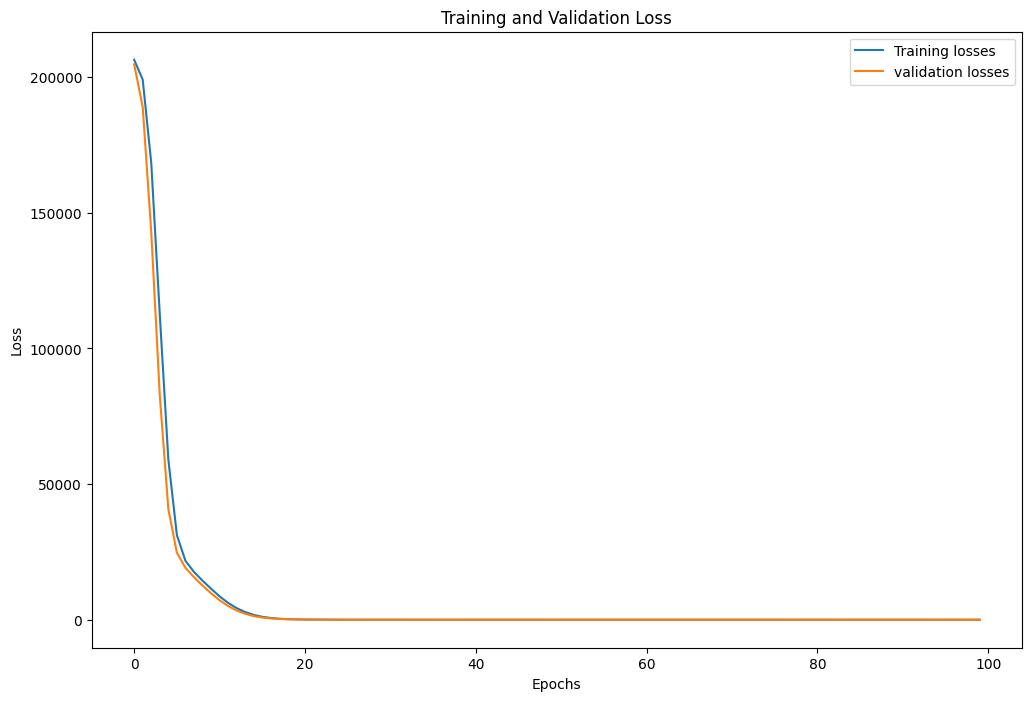

In [15]:
import matplotlib.pyplot as plt
loss_df = pd.DataFrame({
    "Trainning losses":train_losses,
    "validation losses":val_losses
})

plt.figure(figsize=(12,8))
plt.plot(loss_df["Trainning losses"],label = "Training losses")
plt.plot(loss_df["validation losses"],label = "validation losses")

plt.title("Training and Validation Loss") # Added title here
plt.xlabel("Epochs")
plt.ylabel("Loss")

plt.legend()
plt.show()

In [16]:
#Loading the best model
model.load_state_dict(torch.load("best_model.pt")) # fiiting all best weight value to our architecture

<All keys matched successfully>

In [17]:
# Evaluation
model.eval()
with torch.no_grad():
  train_preds = model(x_train_tensor)
  test_preds = model(x_test_tensor)

  train_mse_loss = criterion(train_preds,y_train_tensor)
  test_mse_loss = criterion(test_preds,y_test_tensor)

print("Trainning mse:",train_mse_loss.item())
print("testing mse:",test_mse_loss.item())

Trainning mse: 20.419641494750977
testing mse: 18.8199405670166


In [18]:
from sklearn.metrics import r2_score

print("r^2 score =",r2_score(y_test,test_preds))

r^2 score = 0.9342291636724532


In [19]:
predicted_df = pd.DataFrame(test_preds.numpy(),columns = ["predicted values"])
actual_df = pd.DataFrame(y_test.values,columns=["Actual values"])

pd.concat([predicted_df,actual_df],axis =1)

,predicted values,Actual values
0,435.193512,433.27
1,436.629822,438.16
2,461.287872,458.42
3,476.315643,480.82
4,435.050873,441.41
...,...,...
1909,451.350067,456.70
1910,431.400726,438.04
1911,467.780701,467.80
1912,430.769806,437.14
